In [112]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

%matplotlib inline

# import some common libraries
import numpy as np
import os, json, cv2, random
from IPython.display import Image
from pathlib import Path
import matplotlib.pyplot as plt


# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Wed_Jan_15_19:38:46_Pacific_Standard_Time_2025
Cuda compilation tools, release 12.8, V12.8.61
Build cuda_12.8.r12.8/compiler.35404655_0
torch:  2.6 ; cuda:  cu126
detectron2: 0.6


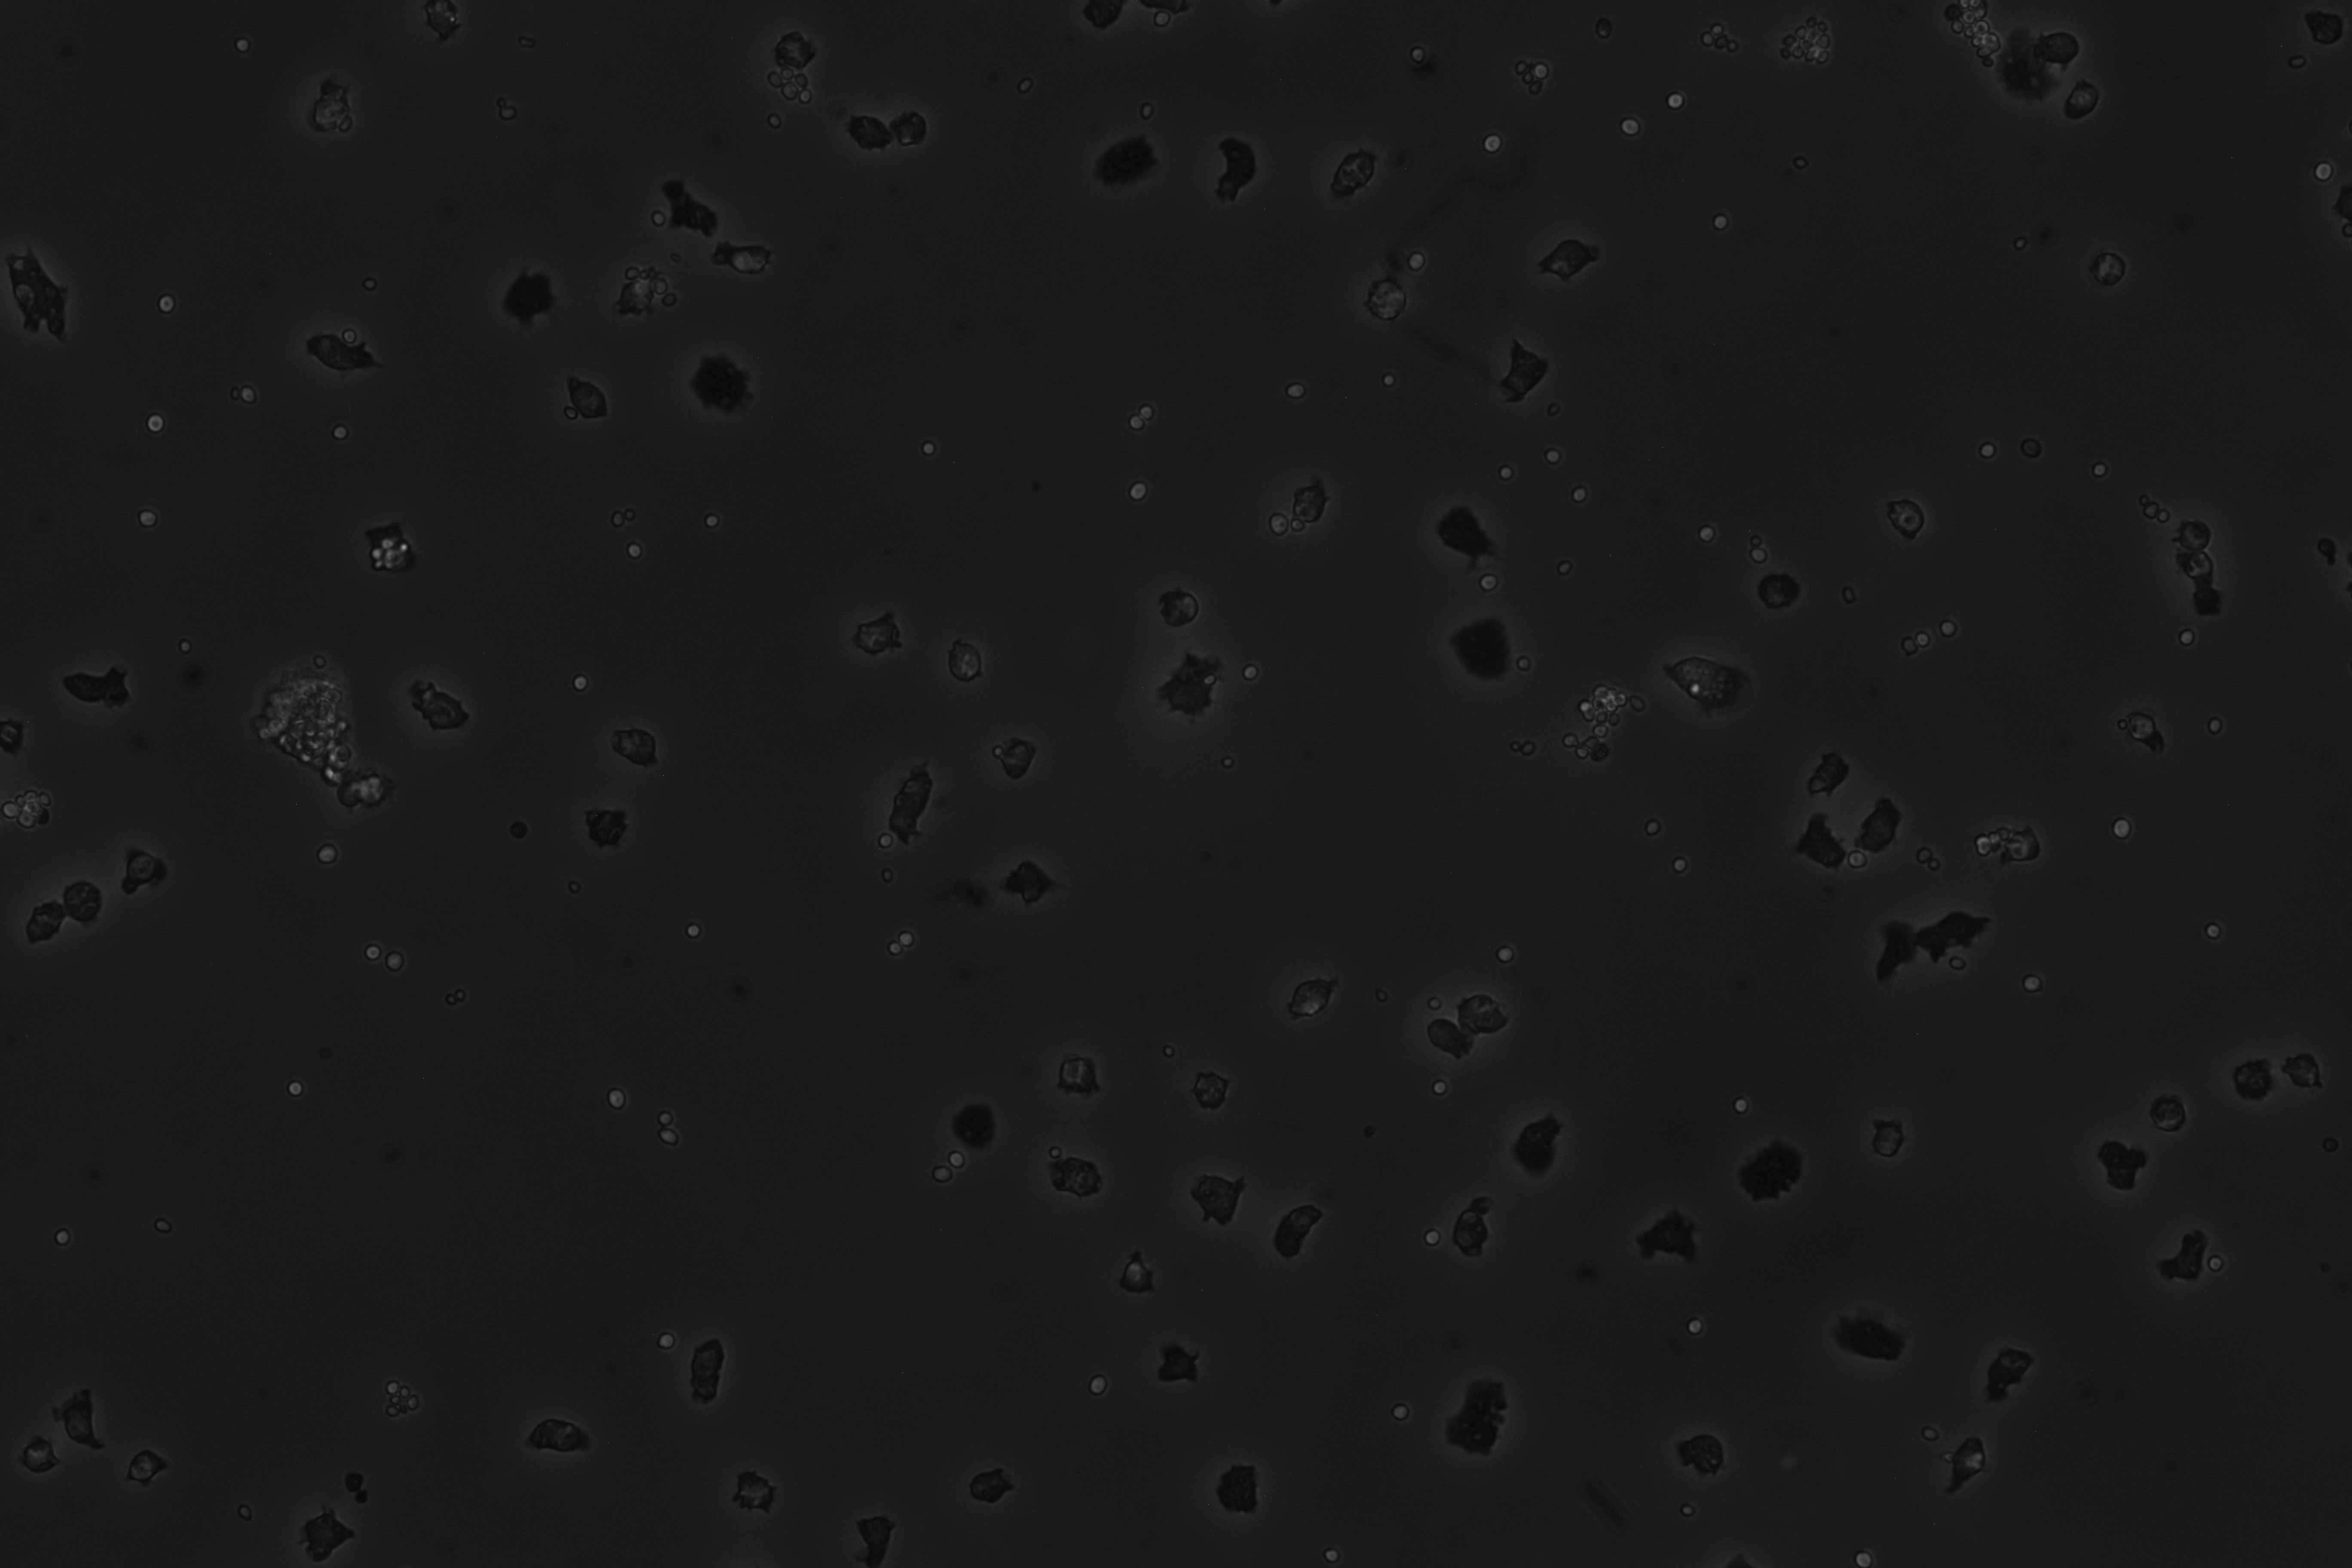

In [118]:
im_path = Path(r"F:\Work\UNI\ResProj\TR-Y4-Project\Tiff_train\tiffTrain_2\train_ims\t_1_MMStack_Default_3.ome.jpg")#
im = cv2.imread(im_path)
im = np.stack([im,im,im])
Image(filename=im_path)

In [ ]:
print(im).shape

[[[[29 29 29]
   [27 27 27]
   [26 26 26]
   ...
   [28 28 28]
   [27 27 27]
   [27 27 27]]

  [[28 28 28]
   [27 27 27]
   [27 27 27]
   ...
   [28 28 28]
   [27 27 27]
   [27 27 27]]

  [[28 28 28]
   [28 28 28]
   [28 28 28]
   ...
   [27 27 27]
   [28 28 28]
   [28 28 28]]

  ...

  [[25 25 25]
   [25 25 25]
   [25 25 25]
   ...
   [28 28 28]
   [29 29 29]
   [31 31 31]]

  [[23 23 23]
   [24 24 24]
   [25 25 25]
   ...
   [28 28 28]
   [29 29 29]
   [31 31 31]]

  [[22 22 22]
   [23 23 23]
   [24 24 24]
   ...
   [26 26 26]
   [27 27 27]
   [29 29 29]]]


 [[[29 29 29]
   [27 27 27]
   [26 26 26]
   ...
   [28 28 28]
   [27 27 27]
   [27 27 27]]

  [[28 28 28]
   [27 27 27]
   [27 27 27]
   ...
   [28 28 28]
   [27 27 27]
   [27 27 27]]

  [[28 28 28]
   [28 28 28]
   [28 28 28]
   ...
   [27 27 27]
   [28 28 28]
   [28 28 28]]

  ...

  [[25 25 25]
   [25 25 25]
   [25 25 25]
   ...
   [28 28 28]
   [29 29 29]
   [31 31 31]]

  [[23 23 23]
   [24 24 24]
   [25 25 25]
   ...
   [2

AttributeError: 'NoneType' object has no attribute 'shape'

: 

In [107]:

cfg = get_cfg()
# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library
# cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training
cfg.MODEL.WEIGHTS = r"F:\Work\UNI\ResProj\TR-Y4-Project\Laptop_model\model_final.pth"
predictor = DefaultPredictor(cfg)
outputs = predictor(im)


[05/01 21:26:07 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from F:\Work\UNI\ResProj\TR-Y4-Project\Laptop_model\model_final.pth ...


Skip loading parameter 'proposal_generator.rpn_head.conv.weight' to the model due to incompatible shapes: (256, 256, 3, 3) in the checkpoint but (1024, 1024, 3, 3) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.conv.bias' to the model due to incompatible shapes: (256,) in the checkpoint but (1024,) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.weight' to the model due to incompatible shapes: (3, 256, 1, 1) in the checkpoint but (15, 1024, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.bias' to the model due to incompatible shapes: (3,) in the checkpoint but (15,) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.anchor_deltas.weight' to the model due to incompatible s

In [ ]:
model = build_model(cfg)
DetectionCheckpointer(model).load(r'F:\Work\UNI\ResProj\TR-Y4-Project\Laptop_model\model_final.pth')

[05/01 21:30:01 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from F:\Work\UNI\ResProj\TR-Y4-Project\Laptop_model\model_final.pth ...


Skip loading parameter 'proposal_generator.rpn_head.conv.weight' to the model due to incompatible shapes: (256, 256, 3, 3) in the checkpoint but (1024, 1024, 3, 3) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.conv.bias' to the model due to incompatible shapes: (256,) in the checkpoint but (1024,) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.weight' to the model due to incompatible shapes: (3, 256, 1, 1) in the checkpoint but (15, 1024, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.bias' to the model due to incompatible shapes: (3,) in the checkpoint but (15,) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.anchor_deltas.weight' to the model due to incompatible s

{'trainer': {'iteration': 5999,
  'hooks': {'LRScheduler': {'base_lrs': [0.00025], 'last_epoch': 6000}},
  '_trainer': {'iteration': 5999,
   'optimizer': {'state': {0: {'momentum_buffer': tensor([[[[ 0.0011]],
      
               [[-0.0008]],
      
               [[ 0.0005]],
      
               ...,
      
               [[ 0.0009]],
      
               [[-0.0006]],
      
               [[ 0.0016]]],
      
      
              [[[ 0.0011]],
      
               [[-0.0007]],
      
               [[-0.0003]],
      
               ...,
      
               [[ 0.0007]],
      
               [[-0.0008]],
      
               [[ 0.0014]]],
      
      
              [[[ 0.0012]],
      
               [[-0.0002]],
      
               [[-0.0025]],
      
               ...,
      
               [[-0.0040]],
      
               [[-0.0032]],
      
               [[-0.0013]]],
      
      
              ...,
      
      
              [[[ 0.0067]],
      
              

In [114]:
model

GeneralizedRCNN(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
        )
      )
      (1): BottleneckBlock(

In [116]:

model.eval()
with torch.no_grad():
  outputs = model(r'F:\Work\UNI\ResProj\TR-Y4-Project\Tiff_train\tiffTrain_1\test_Im')

TypeError: string indices must be integers, not 'str'

In [109]:
# look at the outputs. See https://detectron2.readthedocs.io/tutorials/models.html#model-output-format for specification
print(outputs["instances"].pred_classes)
print(outputs["instances"].pred_boxes)
print(outputs["instances"])

tensor([], device='cuda:0', dtype=torch.int64)
Boxes(tensor([], device='cuda:0', size=(0, 4)))
Instances(num_instances=0, image_height=3648, image_width=5472, fields=[pred_boxes: Boxes(tensor([], device='cuda:0', size=(0, 4))), scores: tensor([], device='cuda:0'), pred_classes: tensor([], device='cuda:0', dtype=torch.int64)])


In [88]:
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
#cv2.imshow('',out.get_image()[:, :, ::-1])

# cv2.imshow('',out.get_image()[:, :, ::-1])
# plt.imshow(out.get_image()[:, :, ::-1])
Image(out.get_image()[:, :, ::-1])

IndexError: tuple index out of range

In [46]:
print(out)